# Student Performance Analysis


### Name : Sambhav Italiya
### Collage Name : Sutex Bank College of Computer Applications & Science

## Objective :
#### To analyze student performance based on study hours, attendance, gender, and parental education, and predict future scores.

## Importing Libraries :


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Loading Dataset :

In [5]:
df = pd.read_csv("../data/student_performance_dataset.csv")

df # printing data

,student_id,gender,study_hours,attendance,parental_education,math,science,history,english
0,1,Male,1.3,52.6,Diploma,20.0,40.0,36.0,25.0
1,2,Female,6.7,76.6,Graduate,53.0,57.0,53.0,54.0
2,3,Male,3.8,77.0,High School,42.0,44.0,40.0,48.0
3,4,Male,5.6,81.9,High School,47.0,54.0,58.0,NaN
4,5,Male,9.2,86.3,High School,69.0,73.0,67.0,74.0
...,...,...,...,...,...,...,...,...,...
195,196,Female,5.7,67.7,High School,52.0,46.0,60.0,41.0
196,197,Female,7.9,79.2,Diploma,73.0,60.0,59.0,65.0
197,198,Female,2.9,53.9,Graduate,36.0,29.0,36.0,39.0
198,199,Male,6.6,98.7,Graduate,61.0,60.0,69.0,56.0


## Data Understanding :


In [6]:
# For Understanding null value and data type of all columns....

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    int64  
 1   gender              200 non-null    object 
 2   study_hours         190 non-null    float64
 3   attendance          190 non-null    float64
 4   parental_education  200 non-null    object 
 5   math                190 non-null    float64
 6   science             190 non-null    float64
 7   history             190 non-null    float64
 8   english             190 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 14.2+ KB


In [7]:
# For Understanding all numerical columns statistics....

df.describe()

,student_id,study_hours,attendance,math,science,history,english
count,200.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000
mean,100.500000,5.776316,73.619737,51.252632,52.868421,54.568421,54.689474
std,57.879185,3.126676,17.840644,17.408548,16.121843,15.674704,15.763913
min,1.000000,1.000000,15.390000,12.000000,19.000000,14.000000,20.000000
25%,50.750000,3.225000,59.025000,39.000000,44.000000,44.000000,44.000000
50%,100.500000,5.750000,74.950000,52.000000,52.000000,55.000000,54.500000
75%,150.250000,7.975000,87.700000,63.000000,62.000000,63.000000,64.000000
max,200.000000,19.600000,99.600000,100.000000,100.000000,100.000000,100.000000


## Checking Missing Values & Outliers :

### > Outliers is extreme values in columns that very diffrent from other data of column.

#### > Checking subject columns for marks is between 1-100 or not....

##### 1. checking min and max values. Between 1 to 100.
##### 2. Checking 50 % is around the mean. If diffrence is huge than it consider as outliers

In [8]:
# For finding missing values....

df.isnull().sum()

student_id             0
gender                 0
study_hours           10
attendance            10
parental_education     0
math                  10
science               10
history               10
english               10
dtype: int64

#### > So some of columns have missing values like study hours, attendance, and all subject marks..!

In [9]:
# Finding outliers of all subject...

print('-----------------math--------------------')
print(df['math'].describe())

print('-----------------science--------------------')
print(df['science'].describe())

print('-----------------history--------------------')
print(df['history'].describe())

print('-----------------english--------------------')
print(df['english'].describe())



-----------------math--------------------
count    190.000000
mean      51.252632
std       17.408548
min       12.000000
25%       39.000000
50%       52.000000
75%       63.000000
max      100.000000
Name: math, dtype: float64
-----------------science--------------------
count    190.000000
mean      52.868421
std       16.121843
min       19.000000
25%       44.000000
50%       52.000000
75%       62.000000
max      100.000000
Name: science, dtype: float64
-----------------history--------------------
count    190.000000
mean      54.568421
std       15.674704
min       14.000000
25%       44.000000
50%       55.000000
75%       63.000000
max      100.000000
Name: history, dtype: float64
-----------------english--------------------
count    190.000000
mean      54.689474
std       15.763913
min       20.000000
25%       44.000000
50%       54.500000
75%       64.000000
max      100.000000
Name: english, dtype: float64


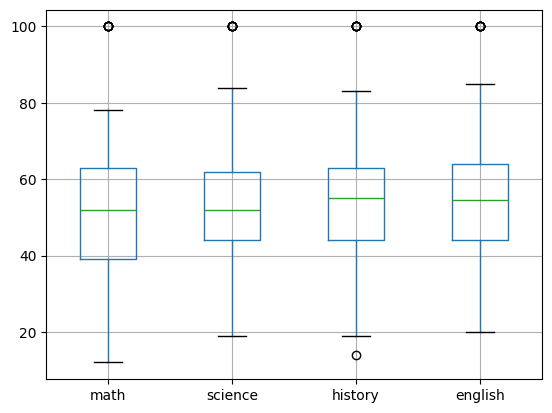

In [10]:
# boxplot of all subjects...

df.boxplot(column=['math','science','history','english'])
plt.show()

In [11]:
df['study_hours'].describe()

count    190.000000
mean       5.776316
std        3.126676
min        1.000000
25%        3.225000
50%        5.750000
75%        7.975000
max       19.600000
Name: study_hours, dtype: float64

In [12]:
sum(df['study_hours'] > 15)  # outliers

3

In [13]:
((df['math'] == 100) & (df['science'] == 100) & (df['history'] == 100) & (df['english'] == 100)).sum() # outliers

np.int64(6)

## Data Cleaning :

### Handle Missing Values....

In [14]:
df.isnull().sum()


student_id             0
gender                 0
study_hours           10
attendance            10
parental_education     0
math                  10
science               10
history               10
english               10
dtype: int64

In [15]:
# Filling missing value using mean of study hours ....

df['study_hours'] = df['study_hours'].fillna(df['study_hours'].mean())

df['study_hours'].isnull().sum()

np.int64(0)

In [16]:
# Filling missing values using mean value of attendance....

df['attendance'] = df['attendance'].fillna(df['attendance'].mean())

df['attendance'].isnull().sum()

np.int64(0)

In [17]:
# Filling missing values using mean of their respective subject ....

df.fillna(df.mean(numeric_only=True), inplace=True)



In [18]:
df.isnull().sum()

student_id            0
gender                0
study_hours           0
attendance            0
parental_education    0
math                  0
science               0
history               0
english               0
dtype: int64

### Removing Outliers...

In [19]:
# rounding the values....

df['math'] = df['math'].round(1)

df['science'] = df['science'].round(1)

df['history'] = df['history'].round(1)

df['english'] = df['english'].round(1)

df['study_hours'] = df['study_hours'].round(0)

df.tail(8)

,student_id,gender,study_hours,attendance,parental_education,math,science,history,english
192,193,Male,8.0,63.90,High School,48.0,62.0,64.0,58.0
193,194,Male,4.0,59.40,Postgraduate,39.0,52.9,54.6,37.0
194,195,Male,4.0,21.96,Diploma,100.0,100.0,100.0,100.0
195,196,Female,6.0,67.70,High School,52.0,46.0,60.0,41.0
196,197,Female,8.0,79.20,Diploma,73.0,60.0,59.0,65.0
197,198,Female,3.0,53.90,Graduate,36.0,29.0,36.0,39.0
198,199,Male,7.0,98.70,Graduate,61.0,60.0,69.0,56.0
199,200,Male,2.0,99.30,High School,33.0,50.0,49.0,53.0


In [20]:
# Replace the outliers using mean of that column through loc...

mean_value = df['study_hours'].mean()

df.loc[df['study_hours'] > 15, 'study_hours'] = mean_value


df.loc[df['study_hours'] > 15]


,student_id,gender,study_hours,attendance,parental_education,math,science,history,english


In [21]:
# Finding and removing outliers...

df.loc[(df['math'] > 99) & (df['science'] > 99) & (df['history'] > 99) & (df['english'] > 99)]

,student_id,gender,study_hours,attendance,parental_education,math,science,history,english
12,13,Male,5.795,15.39,Diploma,100.0,100.0,100.0,100.0
60,61,Male,9.000,20.82,High School,100.0,100.0,100.0,100.0
103,104,Female,5.795,27.39,High School,100.0,100.0,100.0,100.0
126,127,Female,5.795,21.63,Postgraduate,100.0,100.0,100.0,100.0
184,185,Male,12.000,23.76,Postgraduate,100.0,100.0,100.0,100.0
194,195,Male,4.000,21.96,Diploma,100.0,100.0,100.0,100.0


In [22]:
# Delete 6 rows...

cols = ['math','science','history','english']

# condition for who have 100 marks in all subjects....

condition = (df[cols] == 100).all(axis=1)

# remove those rows

df = df[~condition].copy()

##### > Missing values were filled using mean values.
##### > Extreme outliers were remove to improve analysis accuracy.
##### > Now dataset is fully ready for analysis.............

## Feature Engineering :

#### > Adding two new columns for total marks and avrage marks of student....



In [23]:
# Total marks columns.....

df.loc[:, 'total_marks'] = df[['math','science','history','english']].sum(axis=1).round(2)

df['total_marks'].head(5)


0    121.0
1    217.0
2    174.0
3    213.7
4    283.0
Name: total_marks, dtype: float64

In [24]:
# Avearge marks columns...

df.loc[:, 'average_marks'] = (df['total_marks'] / 4).round(2)

df['average_marks'].tail(7)

192    58.00
193    45.88
195    49.75
196    64.25
197    35.00
198    61.50
199    46.25
Name: average_marks, dtype: float64

In [25]:
df

,student_id,gender,study_hours,attendance,parental_education,math,science,history,english,total_marks,average_marks
0,1,Male,1.0,52.6,Diploma,20.0,40.0,36.0,25.0,121.0,30.25
1,2,Female,7.0,76.6,Graduate,53.0,57.0,53.0,54.0,217.0,54.25
2,3,Male,4.0,77.0,High School,42.0,44.0,40.0,48.0,174.0,43.50
3,4,Male,6.0,81.9,High School,47.0,54.0,58.0,54.7,213.7,53.42
4,5,Male,9.0,86.3,High School,69.0,73.0,67.0,74.0,283.0,70.75
...,...,...,...,...,...,...,...,...,...,...,...
195,196,Female,6.0,67.7,High School,52.0,46.0,60.0,41.0,199.0,49.75
196,197,Female,8.0,79.2,Diploma,73.0,60.0,59.0,65.0,257.0,64.25
197,198,Female,3.0,53.9,Graduate,36.0,29.0,36.0,39.0,140.0,35.00
198,199,Male,7.0,98.7,Graduate,61.0,60.0,69.0,56.0,246.0,61.50


## Exploratory Data Analysis (EDA) :

### 1. Impact of study Hours on performance....



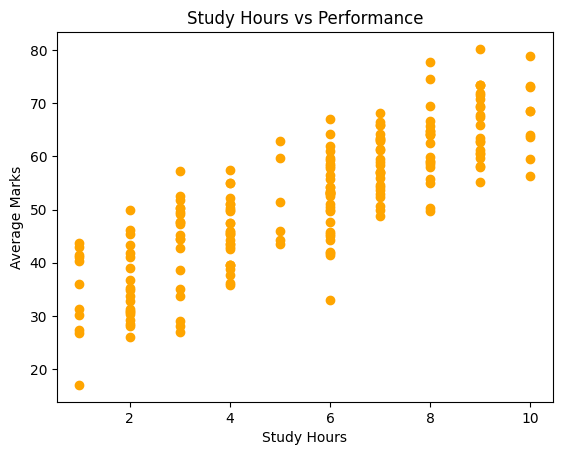

In [26]:
# Using Scatter Plot....

plt.scatter(df['study_hours'], df['average_marks'], color = 'orange')
plt.xlabel("Study Hours")
plt.ylabel("Average Marks")
plt.title("Study Hours vs Performance")

plt.savefig("../output/studyhours_performance.png")  # save

plt.show()

#### >>> There is a positive relationship between study hours and student performance. Those students give more     hours to their study their are getting more marks.

### 2. Effect of attendance on performance....

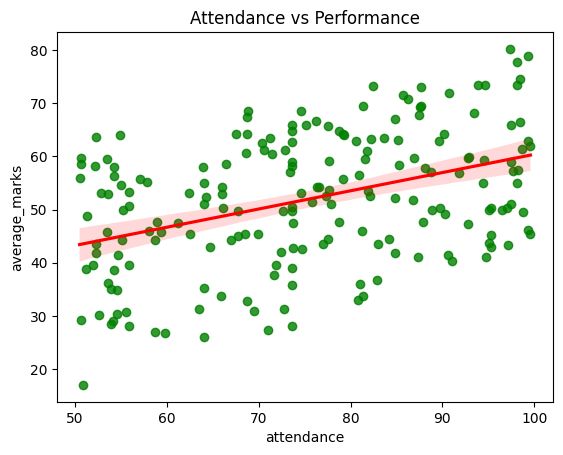

In [27]:
# Using Regression Plot....


sns.regplot(x='attendance', y='average_marks', data=df,
            scatter_kws={'color':'green'},
            line_kws={'color':'red'})
plt.title("Attendance vs Performance")

plt.savefig("../output/attendance_per.png")  # save

plt.show()

#### >>>> Attendance has a strong positive impact on student performance. Those students are less attendance loosing their performance in study.

### 3. Gender-Wise Performance....

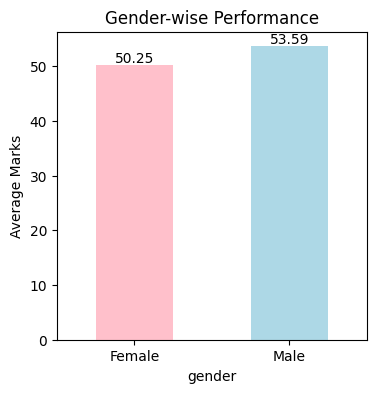

In [28]:
# Using Bar chart.....


plt.figure(figsize=(4,4)) 

data = df.groupby('gender')['average_marks'].mean()

bars = data.plot(kind='bar', color = ['pink', 'lightblue'])

for i, v in enumerate(data):
    plt.text(i, v + 0.5, round(v,2), ha='center')

plt.xticks(rotation=360)

plt.title("Gender-wise Performance")
plt.ylabel("Average Marks")

plt.savefig("../output/genderwise.png")  # save

plt.show()

### 4. Subject-wise Performance....

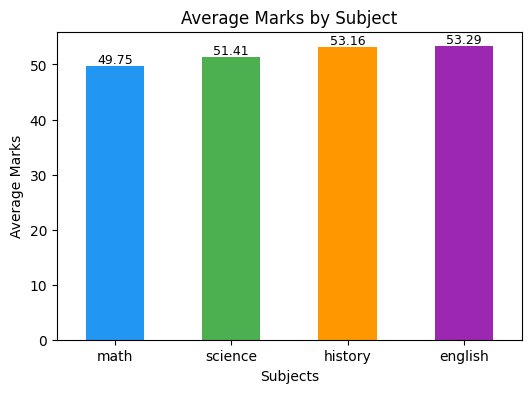

In [41]:
plt.figure(figsize=(6,4))

subjects = ['math','science','history','english']
data = df[subjects].mean()

data.plot(kind='bar', color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])

for i, v in enumerate(data):
    plt.text(i, v + 0.5, f"{v:.2f}", ha='center', fontsize=9)

plt.xticks(rotation=360)

plt.title("Average Marks by Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")

plt.savefig("../output/subject wise.png")  # save

plt.show()

## Correlation Analysis :

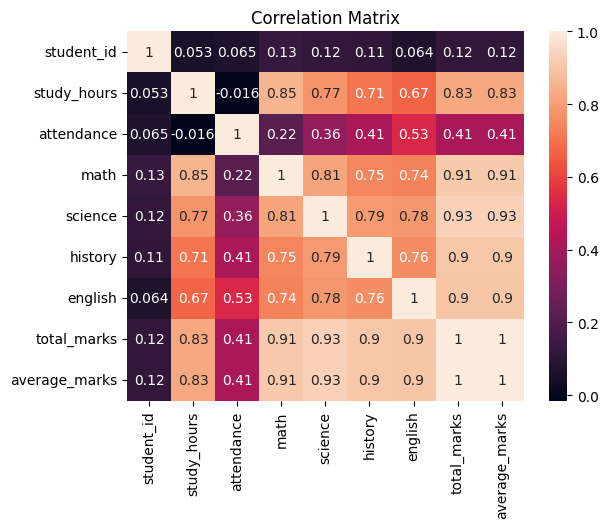

In [34]:
# Heatmap....

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")

plt.savefig("../output/correlation.png")  # save 

plt.show()

#### >>>> Study hours and attendance are positively correlated with marks.

## Prediction final score :


#### Predict student average marks using:
#### >>>> Study Hours.
#### >>>> Attendance.

In [31]:
# Prepare the data for modek....

from sklearn.model_selection import train_test_split

X = df[['study_hours','attendance']] # input features.
y = df['average_marks']              # Target featur.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [35]:
# Train model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
# Checking model accuracy....

model.score(X_test, y_test)

0.8942987733522235

In [37]:
# Prediction example....

# first argument is study hours and second is attendance.

# The model predicts student marks based on study hours and attendance.


model.predict([[7, 85]])

C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([61.45423403])

## Grade Classification :

In [39]:
# Function of grade classification....

def grade(avg):
    
    if avg >= 90:
        return 'A'
        
    elif avg >= 75:
        return 'B'
        
    elif avg >= 50:
        return 'C'
        
    elif avg >=30:
        return 'D'
        
    else:
        return 'Fail'

df['grade'] = df['average_marks'].apply(grade)

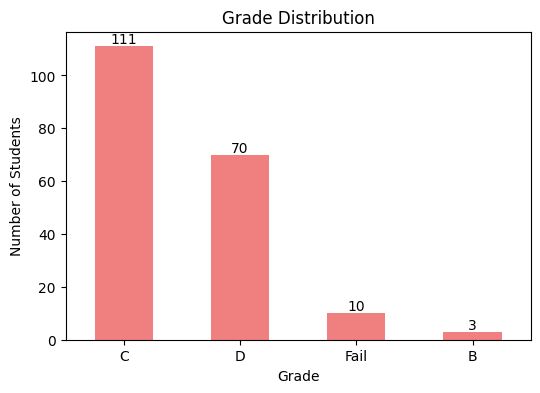

In [42]:
# Bar Chart for grade distribution.....

plt.figure(figsize=(6,4))

counts = df['grade'].value_counts()

counts.plot(kind='bar', color = 'lightcoral')

for i, v in enumerate(counts):
    plt.text(i, v + 1, str(v), ha='center')

plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Number of Students")

plt.xticks(rotation=360)

plt.savefig("../output/grade.png")  # save

plt.show()